# 제3장 백테스팅 - 종합 분석 노트북

> **출처:** Ernest Chan, *Quantitative Trading* (2nd Ed., 2021), Chapter 3  
> **분석 기반:** `run_chapter3_analysis.py`

---

## 개요 및 문제 정의

백테스팅(Backtesting)은 과거 데이터를 사용하여 트레이딩 전략의 성과를 검증하는 과정이다.
이 챕터에서는 다음 핵심 성과 지표와 전략을 다룬다.

### 핵심 수식

**샤프 비율(Sharpe Ratio)** 의 연율화:

$$
\text{Annualized Sharpe Ratio} = \sqrt{N_T} \times \frac{\bar{R} - r_f}{\sigma_R}
$$

여기서 $N_T$ 는 연간 거래 기간 수(일별이면 252), $\bar{R}$ 은 기간 평균 수익률, $r_f$ 는 무위험이자율, $\sigma_R$ 은 수익률 표준편차이다.

**최대 낙폭(Maximum Drawdown):**

$$
\text{MDD} = \min_t \left( \frac{1 + \text{CumRet}(t)}{1 + \text{HWM}(t)} - 1 \right)
$$

여기서 $\text{HWM}(t) = \max_{s \le t} \text{CumRet}(s)$ 는 고수위선(High Water Mark)이다.

**달러-중립 포트폴리오** 의 경우, 자기금융(self-financing) 특성상 무위험이자율 차감이 불필요하다.

### 예제 구성

| 예제 | 내용 | 핵심 개념 |
|------|------|-----------|
| 3.1 | Yahoo Finance 데이터 다운로드 | 데이터 수집 (MATLAB/Python/R) |
| 3.2 | 주식분할/배당 조정 | 데이터 전처리 (MATLAB/Excel) |
| 3.3 | 생존자 편향 영향 | 데이터 품질 (MATLAB/Excel) |
| 3.4 | 샤프 비율 계산 | 롱온리 vs 시장중립 |
| 3.5 | 최대 낙폭 계산 | MDD, MDD Duration |
| 3.6 | GLD-GDX 페어 트레이딩 | 공적분, z-score 진입/청산 |
| 3.7 | 횡단면 평균회귀 (종가) | 거래비용 영향 분석 |
| 3.8 | 횡단면 평균회귀 (시가) | 시가 vs 종가 비교 |

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# 경로 설정 (노트북이 src/ 디렉토리에 위치한다고 가정)
PROJECT_ROOT = Path("..").resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
UTIL_DIR = PROJECT_ROOT / "src"

# 공유 유틸리티 임포트
sys.path.insert(0, str(UTIL_DIR))
from calculateMaxDD import calculateMaxDD

# matplotlib 스타일 설정
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

def read_excel_safe(path, **kwargs):
    """XLS 파일을 읽되, calamine 엔진 우선 사용 후 폴백"""
    try:
        return pd.read_excel(path, engine='calamine', **kwargs)
    except (ImportError, Exception):
        return pd.read_excel(path, **kwargs)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"데이터 디렉토리 존재: {DATA_DIR.exists()}")

PROJECT_ROOT: /media/restful3/data/workspace/ml4t/source/Chan E. Quantitative Trading...Build...Trading Business 2ed 2021
DATA_DIR: /media/restful3/data/workspace/ml4t/source/Chan E. Quantitative Trading...Build...Trading Business 2ed 2021/data
데이터 디렉토리 존재: True


## 사용 데이터

| 파일명 | 형식 | 설명 | 사용 예제 |
|--------|------|------|-----------|
| `IGE.xls` | XLS | iShares North American Natural Resources ETF | 3.4, 3.5 |
| `SPY.xls` | XLS | SPDR S&P 500 ETF Trust | 3.4 |
| `GLD.xls` | XLS | SPDR Gold Trust | 3.6 |
| `GDX.xls` | XLS | VanEck Gold Miners ETF | 3.6 |
| `SPX_20071123.txt` | TSV | S&P 500 구성 종목 종가 | 3.7 |
| `SPX_op_20071123.txt` | TSV | S&P 500 구성 종목 시가 | 3.8 |

In [2]:
# --- IGE 데이터 ---
df_ige = read_excel_safe(DATA_DIR / "IGE.xls")
df_ige.sort_values(by="Date", inplace=True)
df_ige.reset_index(drop=True, inplace=True)
print(f"IGE: {df_ige.shape}, {df_ige['Date'].iloc[0].date()} ~ {df_ige['Date'].iloc[-1].date()}")

# --- SPY 데이터 ---
df_spy = read_excel_safe(DATA_DIR / "SPY.xls")
df_spy.sort_values(by="Date", inplace=True)
df_spy.reset_index(drop=True, inplace=True)
print(f"SPY: {df_spy.shape}, {df_spy['Date'].iloc[0].date()} ~ {df_spy['Date'].iloc[-1].date()}")

# --- GLD 데이터 ---
df_gld = read_excel_safe(DATA_DIR / "GLD.xls")
df_gld.sort_values(by="Date", inplace=True)
df_gld.reset_index(drop=True, inplace=True)
print(f"GLD: {df_gld.shape}, {df_gld['Date'].iloc[0].date()} ~ {df_gld['Date'].iloc[-1].date()}")

# --- GDX 데이터 ---
df_gdx = read_excel_safe(DATA_DIR / "GDX.xls")
df_gdx.sort_values(by="Date", inplace=True)
df_gdx.reset_index(drop=True, inplace=True)
print(f"GDX: {df_gdx.shape}, {df_gdx['Date'].iloc[0].date()} ~ {df_gdx['Date'].iloc[-1].date()}")

# --- SPX 종가 데이터 (횡단면 전략) ---
df_spx_cl = pd.read_table(DATA_DIR / "SPX_20071123.txt")
df_spx_cl["Date"] = df_spx_cl["Date"].astype("int")
df_spx_cl.set_index("Date", inplace=True)
df_spx_cl.sort_index(inplace=True)
print(f"SPX 종가: {df_spx_cl.shape[0]} 거래일 x {df_spx_cl.shape[1]} 종목")

# --- SPX 시가 데이터 ---
df_spx_op = pd.read_table(DATA_DIR / "SPX_op_20071123.txt")
df_spx_op["Date"] = df_spx_op["Date"].astype("int")
df_spx_op.set_index("Date", inplace=True)
df_spx_op.sort_index(inplace=True)
print(f"SPX 시가: {df_spx_op.shape[0]} 거래일 x {df_spx_op.shape[1]} 종목")

# 데이터 미리보기
print("\n--- IGE head ---")
display(df_ige.head(3))
print("\n--- SPX 종가 head ---")
display(df_spx_cl.iloc[:3, :5])

IGE: (1504, 7), 2001-11-26 ~ 2007-11-14
SPY: (1504, 7), 2001-11-26 ~ 2007-11-14
GLD: (764, 7), 2004-11-18 ~ 2007-11-30
GDX: (385, 7), 2006-05-23 ~ 2007-11-30
SPX 종가: 2024 거래일 x 500 종목
SPX 시가: 2024 거래일 x 500 종목

--- IGE head ---


,Date,Open,High,Low,Close,Volume,Adj Close
0,2001-11-26,91.01,91.01,91.01,91.01,0,42.09
1,2001-11-27,91.01,91.01,91.01,91.01,0,42.09
2,2001-11-28,91.01,91.01,91.01,91.01,0,42.09



--- SPX 종가 head ---


,A,AA,AAPL,ABC,ABI
Date,,,,,
19991124,41.1250,20.3772,23.6563,5.9980,NaN
19991126,41.1875,20.6142,23.7656,5.9980,NaN
19991129,42.0000,20.5352,23.6406,5.9675,NaN


---

## 분석 1: 샤프 비율 계산 (예제 3.4)

IGE 롱온리 전략과 IGE-SPY 시장중립 전략의 샤프 비율을 비교한다.

- **롱온리(Long-Only):** IGE를 매수 보유. 초과수익률 = 일간 수익률 - 무위험이자율($r_f = 4\%$ 연율화)
- **시장중립(Market Neutral):** IGE 매수 + SPY 매도 (달러-중립). 달러-중립이므로 $r_f$ 를 차감하지 않음

$$
\text{SR}_{\text{long}} = \sqrt{252} \times \frac{\bar{R}_{\text{IGE}} - r_f}{\sigma_{\text{IGE}}}
\qquad
\text{SR}_{\text{neutral}} = \sqrt{252} \times \frac{\bar{R}_{\text{IGE-SPY}}}{\sigma_{\text{IGE-SPY}}}
$$

[1] IGE 롱온리 전략
    일간 평균 수익률:    0.000829
    일간 수익률 표준편차: 0.013490
    연율화 샤프 비율:    0.7896

[2] IGE-SPY 시장중립 전략
    일간 평균 순수익률:   0.000278
    일간 순수익률 표준편차: 0.005622
    연율화 샤프 비율:     0.7839


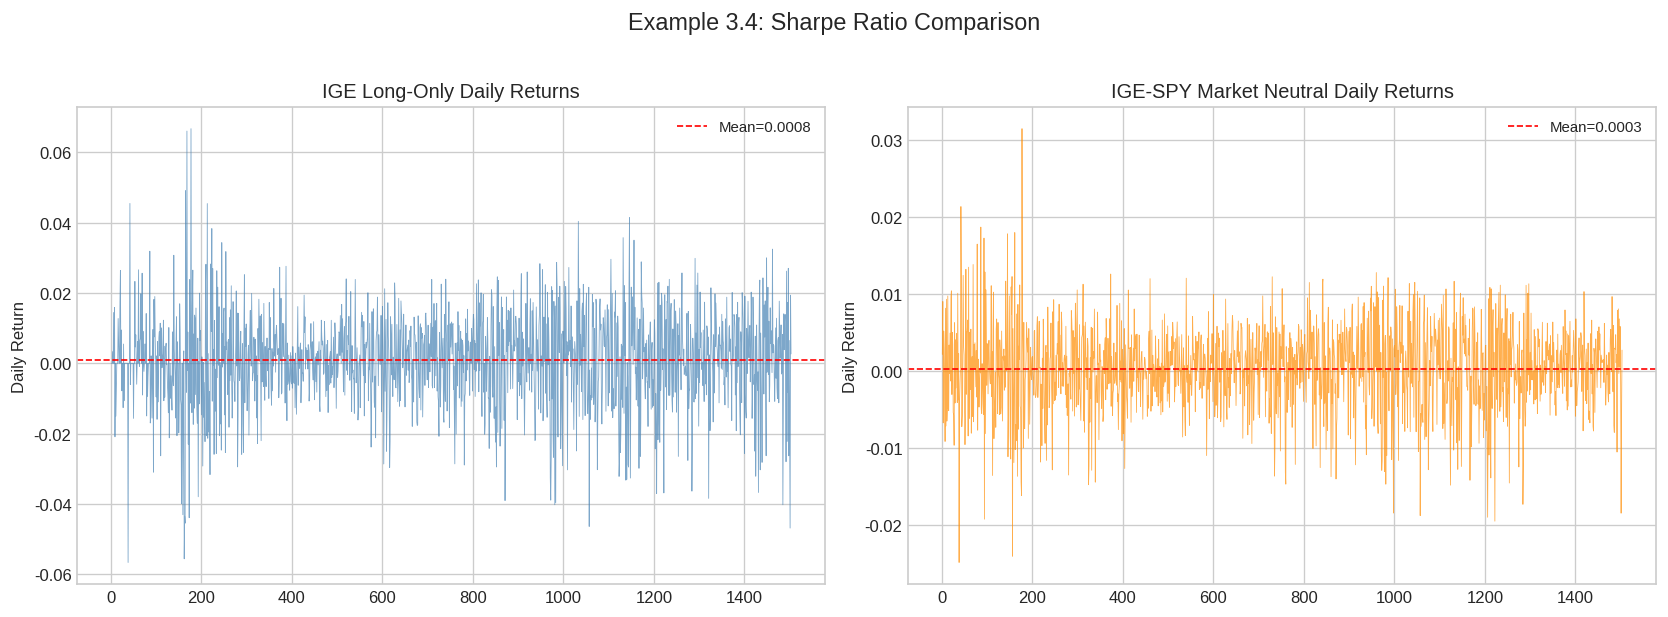

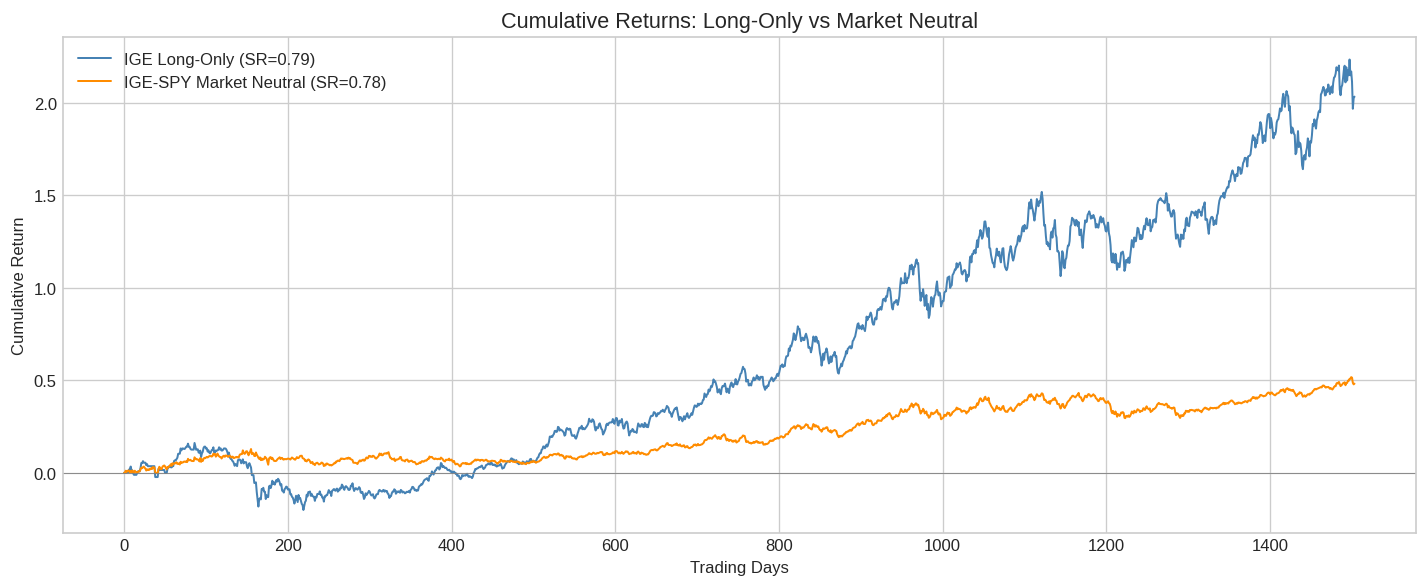

In [3]:
# ============================
# 1) IGE 롱온리 전략
# ============================
ige_daily_ret = df_ige["Adj Close"].pct_change()
rf_daily = 0.04 / 252  # 연 4% 무위험이자율
excess_ret = ige_daily_ret - rf_daily
sharpe_long = float(np.sqrt(252) * np.mean(excess_ret.dropna()) / np.std(excess_ret.dropna()))

print(f"[1] IGE 롱온리 전략")
print(f"    일간 평균 수익률:    {ige_daily_ret.mean():.6f}")
print(f"    일간 수익률 표준편차: {ige_daily_ret.std():.6f}")
print(f"    연율화 샤프 비율:    {sharpe_long:.4f}")

# ============================
# 2) IGE-SPY 시장중립 전략
# ============================
df_merged = pd.merge(df_ige, df_spy, on="Date", suffixes=("_IGE", "_SPY"))
df_merged["Date"] = pd.to_datetime(df_merged["Date"])
df_merged.set_index("Date", inplace=True)
df_merged.sort_index(inplace=True)

daily_ret = df_merged[["Adj Close_IGE", "Adj Close_SPY"]].pct_change()
daily_ret.rename(columns={"Adj Close_IGE": "IGE", "Adj Close_SPY": "SPY"}, inplace=True)

# 시장중립: (IGE - SPY) / 2
net_ret = (daily_ret["IGE"] - daily_ret["SPY"]) / 2
sharpe_neutral = float(np.sqrt(252) * np.mean(net_ret.dropna()) / np.std(net_ret.dropna()))

print(f"\n[2] IGE-SPY 시장중립 전략")
print(f"    일간 평균 순수익률:   {net_ret.mean():.6f}")
print(f"    일간 순수익률 표준편차: {net_ret.std():.6f}")
print(f"    연율화 샤프 비율:     {sharpe_neutral:.4f}")

# ============================
# 차트 1: 일간 수익률 비교
# ============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ige_daily_ret.values, linewidth=0.5, alpha=0.7, color='steelblue')
axes[0].axhline(y=ige_daily_ret.mean(), color='red', linestyle='--',
                linewidth=1, label=f'Mean={ige_daily_ret.mean():.4f}')
axes[0].set_title('IGE Long-Only Daily Returns', fontsize=12)
axes[0].set_ylabel('Daily Return')
axes[0].legend(fontsize=9)

axes[1].plot(net_ret.values, linewidth=0.5, alpha=0.7, color='darkorange')
axes[1].axhline(y=net_ret.mean(), color='red', linestyle='--',
                linewidth=1, label=f'Mean={net_ret.mean():.4f}')
axes[1].set_title('IGE-SPY Market Neutral Daily Returns', fontsize=12)
axes[1].set_ylabel('Daily Return')
axes[1].legend(fontsize=9)

fig.suptitle('Example 3.4: Sharpe Ratio Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================
# 차트 2: 누적 수익률 비교
# ============================
fig2, ax2 = plt.subplots(figsize=(12, 5))
cum_long = (1 + ige_daily_ret.fillna(0)).cumprod() - 1
cum_neutral = (1 + net_ret.fillna(0)).cumprod() - 1
ax2.plot(cum_long.values, label=f'IGE Long-Only (SR={sharpe_long:.2f})',
         linewidth=1.2, color='steelblue')
ax2.plot(cum_neutral.values,
         label=f'IGE-SPY Market Neutral (SR={sharpe_neutral:.2f})',
         linewidth=1.2, color='darkorange')
ax2.set_title('Cumulative Returns: Long-Only vs Market Neutral', fontsize=13)
ax2.set_ylabel('Cumulative Return')
ax2.set_xlabel('Trading Days')
ax2.legend(fontsize=10)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 결과 해석

| 지표 | 롱온리 (IGE) | 시장중립 (IGE-SPY) |
|------|:------------:|:-----------------:|
| 일간 평균 수익률 | 0.000829 | 0.000278 |
| 일간 수익률 표준편차 | 0.013490 | 0.005622 |
| **연율화 샤프 비율** | **0.7896** | **0.7839** |

IGE 롱온리 전략의 샤프 비율이 더 높다. 이 기간 동안 에너지 섹터의 강세장이 시장중립 전략보다 유리했다.

**주의:** 시장중립 전략의 경우 달러-중립이므로 무위험이자율을 차감하지 않았다.

---

## 분석 2: 최대 낙폭 (예제 3.5)

IGE-SPY 시장중립 전략의 누적 복리 수익률에서 **최대 낙폭(Maximum Drawdown)** 을 계산한다.

- 고수위선(High Water Mark) 대비 현재 누적 수익률의 최대 하락 폭을 측정
- MDD 지속기간(Maximum Drawdown Duration): 고수위선 회복까지 걸린 최장 기간

$$
\text{Drawdown}(t) = \frac{1 + \text{CumRet}(t)}{1 + \text{HWM}(t)} - 1
$$

시장중립(IGE-SPY) 전략 최대 낙폭 분석:
  최대 낙폭 (Max Drawdown):        -0.0953 (-9.53%)
  최대 낙폭 지속기간 (Max DD Dur):  497 거래일
  최대 낙폭 발생일 인덱스:          1222


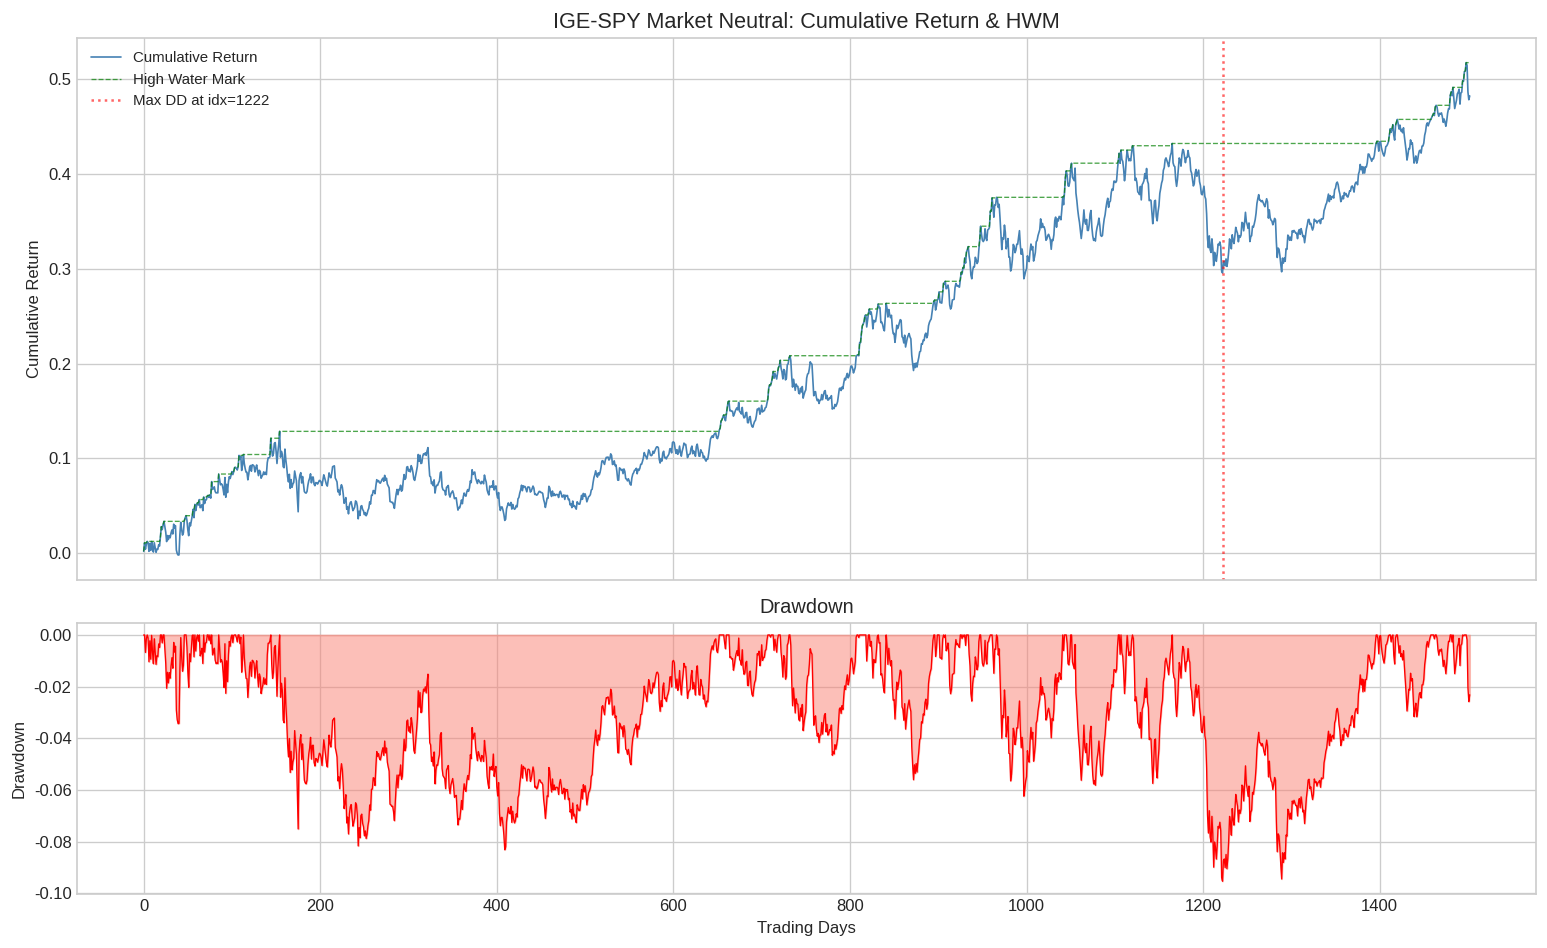

In [4]:
# 누적 복리 수익률 (시장중립 전략)
net_ret_clean = net_ret.dropna()
cum_ret = np.cumprod(1 + net_ret_clean.values) - 1

# calculateMaxDD 호출
max_dd, max_ddd, dd_start_idx = calculateMaxDD(cum_ret)

print(f"시장중립(IGE-SPY) 전략 최대 낙폭 분석:")
print(f"  최대 낙폭 (Max Drawdown):        {max_dd:.4f} ({max_dd*100:.2f}%)")
print(f"  최대 낙폭 지속기간 (Max DD Dur):  {int(max_ddd)} 거래일")
print(f"  최대 낙폭 발생일 인덱스:          {int(dd_start_idx)}")

# --- 시각화: 누적 수익률 + 낙폭 ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# 누적 수익률
axes[0].plot(cum_ret, linewidth=1.0, color='steelblue', label='Cumulative Return')
hwm = np.maximum.accumulate(cum_ret)
axes[0].plot(hwm, linewidth=0.8, color='green', linestyle='--',
             alpha=0.7, label='High Water Mark')
axes[0].axvline(x=dd_start_idx, color='red', linestyle=':', alpha=0.6,
                label=f'Max DD at idx={dd_start_idx}')
axes[0].set_title('IGE-SPY Market Neutral: Cumulative Return & HWM', fontsize=13)
axes[0].set_ylabel('Cumulative Return')
axes[0].legend(fontsize=9)

# 낙폭 시계열
drawdown = (1 + cum_ret) / (1 + hwm) - 1
axes[1].fill_between(range(len(drawdown)), drawdown, 0, color='salmon', alpha=0.5)
axes[1].plot(drawdown, linewidth=0.8, color='red')
axes[1].set_title('Drawdown', fontsize=12)
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Trading Days')

plt.tight_layout()
plt.show()

### 결과 해석

| 지표 | 값 |
|------|---:|
| 최대 낙폭 (MDD) | -9.53% |
| 최대 낙폭 지속기간 | 497 거래일 |
| MDD 발생 인덱스 | 1222 |

최대 낙폭 -9.5%는 양호한 수준이다. 그러나 MDD 지속기간이 497 거래일(약 2년)로 긴 편이므로,
실전에서는 투자자의 인내심이 시험받을 수 있다.

---

## 분석 3: GLD-GDX 페어 트레이딩 (예제 3.6)

GLD(금 ETF)와 GDX(금광 ETF) 간의 페어 트레이딩 전략이다.
학습 기간에서 OLS로 헤지 비율을 추정하고, z-score 기반으로 진입/청산한다.

**전략 로직:**
1. 학습 기간(첫 252 거래일)에서 OLS 회귀: $\text{GLD} = \beta \cdot \text{GDX} + \epsilon$
2. 스프레드: $S = \text{GLD} - \beta \cdot \text{GDX}$
3. z-score: $z = (S - \bar{S}) / \sigma_S$ (학습 기간의 평균/표준편차 사용)
4. 진입: $|z| \ge 2$, 청산: $|z| \le 1$

학습 기간: 2006-05-23 ~ 2007-05-23 (252일)
테스트 기간: 2007-05-24 ~ 2007-11-30 (133일)

헤지 비율 (Hedge Ratio): 1.6310
OLS R-squared: 0.9990
스프레드 평균 (학습): 0.0522
스프레드 표준편차 (학습): 1.9449

--- 성과 요약 ---
학습 샤프 비율:  1.9183
테스트 샤프 비율: 1.4943
테스트 최대 낙폭: -0.0702 (-7.02%)
테스트 MDD 지속:  13 거래일


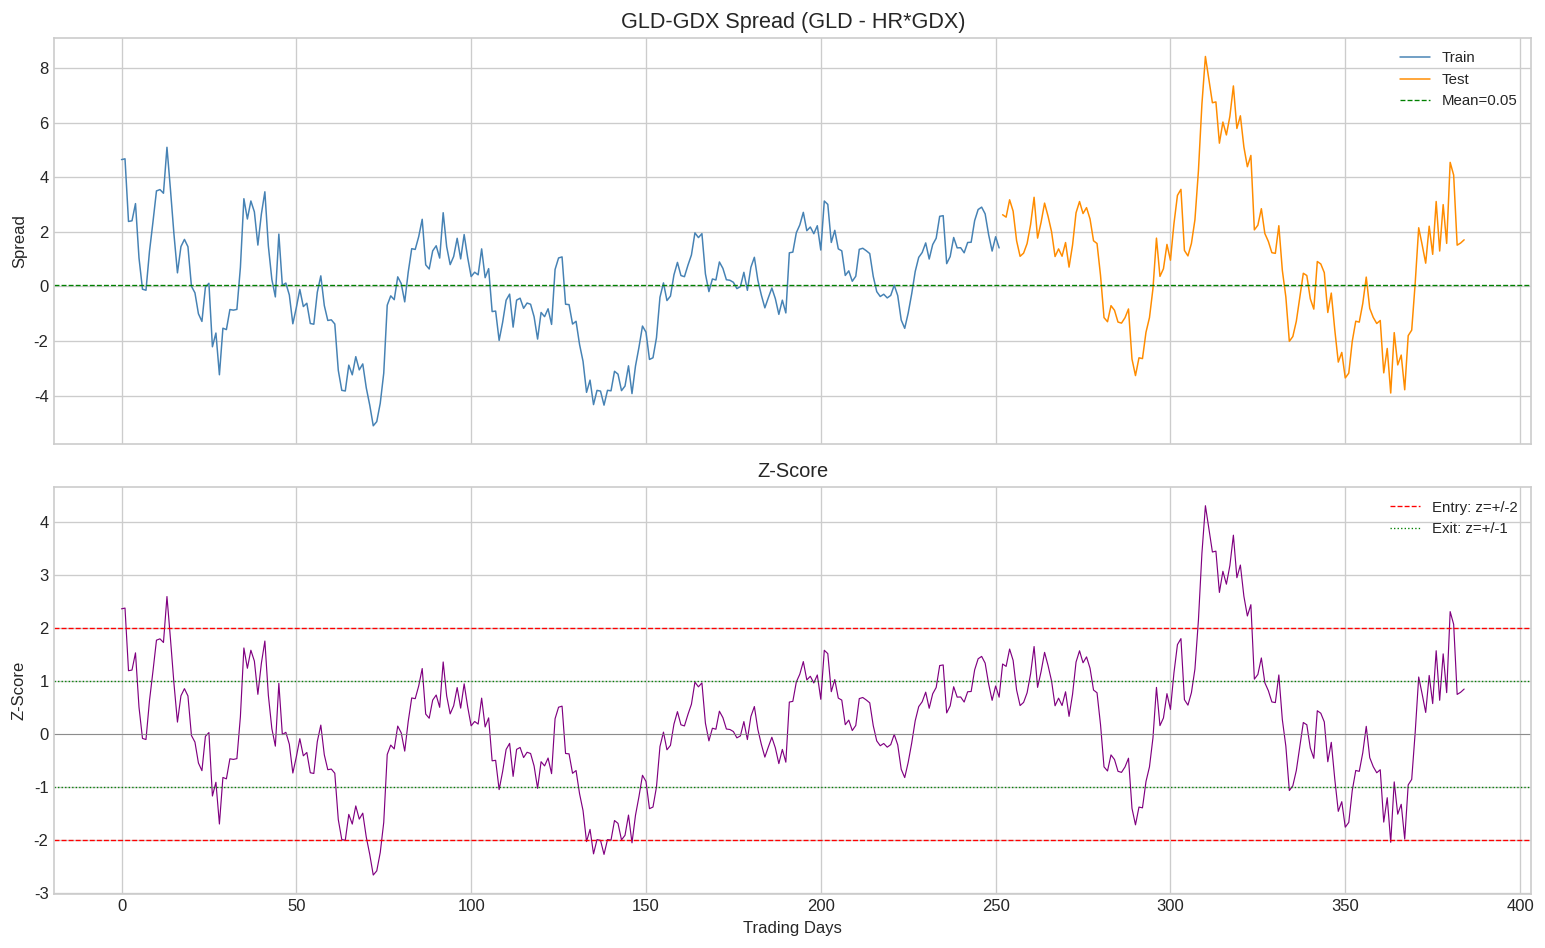

In [5]:
# 데이터 병합
df_pair = pd.merge(df_gld, df_gdx, on="Date", suffixes=("_GLD", "_GDX"))
df_pair.set_index("Date", inplace=True)
df_pair.sort_index(inplace=True)

# 학습/테스트 분할
trainset = np.arange(0, 252)
testset = np.arange(trainset.shape[0], df_pair.shape[0])
print(f"학습 기간: {df_pair.index[trainset[0]].date()} ~ {df_pair.index[trainset[-1]].date()} ({len(trainset)}일)")
print(f"테스트 기간: {df_pair.index[testset[0]].date()} ~ {df_pair.index[testset[-1]].date()} ({len(testset)}일)")

# --- OLS 헤지 비율 추정 ---
model = sm.OLS(
    df_pair["Adj Close_GLD"].iloc[trainset],
    df_pair["Adj Close_GDX"].iloc[trainset]
)
results_ols = model.fit()
hedge_ratio = results_ols.params.iloc[0]
print(f"\n헤지 비율 (Hedge Ratio): {hedge_ratio:.4f}")
print(f"OLS R-squared: {results_ols.rsquared:.4f}")

# --- 스프레드 및 z-score ---
spread = df_pair["Adj Close_GLD"] - hedge_ratio * df_pair["Adj Close_GDX"]
spread_mean = np.mean(spread.iloc[trainset])
spread_std = np.std(spread.iloc[trainset])
df_pair["zscore"] = (spread - spread_mean) / spread_std
print(f"스프레드 평균 (학습): {spread_mean:.4f}")
print(f"스프레드 표준편차 (학습): {spread_std:.4f}")

# --- 포지션 생성 ---
df_pair["pos_GLD_Long"] = 0.0
df_pair["pos_GDX_Long"] = 0.0
df_pair["pos_GLD_Short"] = 0.0
df_pair["pos_GDX_Short"] = 0.0

# 숏 스프레드: z >= 2 -> GLD 숏, GDX 롱
df_pair.loc[df_pair.zscore >= 2, ("pos_GLD_Short", "pos_GDX_Short")] = [-1, 1]
# 롱 스프레드: z <= -2 -> GLD 롱, GDX 숏
df_pair.loc[df_pair.zscore <= -2, ("pos_GLD_Long", "pos_GDX_Long")] = [1, -1]
# 숏 스프레드 청산: z <= 1
df_pair.loc[df_pair.zscore <= 1, ("pos_GLD_Short", "pos_GDX_Short")] = 0
# 롱 스프레드 청산: z >= -1
df_pair.loc[df_pair.zscore >= -1, ("pos_GLD_Long", "pos_GDX_Long")] = 0

# ffill로 포지션 유지
df_pair[["pos_GLD_Long", "pos_GDX_Long",
         "pos_GLD_Short", "pos_GDX_Short"]] = (
    df_pair[["pos_GLD_Long", "pos_GDX_Long",
             "pos_GLD_Short", "pos_GDX_Short"]].ffill()
)

positions_long = df_pair[["pos_GLD_Long", "pos_GDX_Long"]]
positions_short = df_pair[["pos_GLD_Short", "pos_GDX_Short"]]
positions = np.array(positions_long) + np.array(positions_short)
positions_df = pd.DataFrame(positions, index=df_pair.index, columns=["GLD", "GDX"])

# --- PnL 계산 ---
pair_daily_ret = df_pair[["Adj Close_GLD", "Adj Close_GDX"]].pct_change()
pnl = (np.array(positions_df.shift()) * np.array(pair_daily_ret)).sum(axis=1)

sharpe_train = float(np.sqrt(252) * np.mean(pnl[trainset[1:]]) / np.std(pnl[trainset[1:]]))
sharpe_test = float(np.sqrt(252) * np.mean(pnl[testset]) / np.std(pnl[testset]))

# MDD (테스트 기간)
cum_ret_test = np.cumprod(1 + pnl[testset]) - 1
mdd_test, mdd_dur_test, _ = calculateMaxDD(cum_ret_test)

print(f"\n--- 성과 요약 ---")
print(f"학습 샤프 비율:  {sharpe_train:.4f}")
print(f"테스트 샤프 비율: {sharpe_test:.4f}")
print(f"테스트 최대 낙폭: {mdd_test:.4f} ({mdd_test*100:.2f}%)")
print(f"테스트 MDD 지속:  {int(mdd_dur_test)} 거래일")

# --- 시각화: 스프레드 및 z-score ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(spread.iloc[trainset].values, label='Train', color='steelblue', linewidth=0.9)
axes[0].plot(range(len(trainset), len(trainset) + len(testset)),
             spread.iloc[testset].values, label='Test', color='darkorange', linewidth=0.9)
axes[0].axhline(y=spread_mean, color='green', linestyle='--', linewidth=0.8,
                label=f'Mean={spread_mean:.2f}')
axes[0].set_title('GLD-GDX Spread (GLD - HR*GDX)', fontsize=13)
axes[0].set_ylabel('Spread')
axes[0].legend(fontsize=9)

zscore_vals = df_pair["zscore"].values
axes[1].plot(zscore_vals, linewidth=0.7, color='purple')
axes[1].axhline(y=2, color='red', linestyle='--', linewidth=0.8, label='Entry: z=+/-2')
axes[1].axhline(y=-2, color='red', linestyle='--', linewidth=0.8)
axes[1].axhline(y=1, color='green', linestyle=':', linewidth=0.8, label='Exit: z=+/-1')
axes[1].axhline(y=-1, color='green', linestyle=':', linewidth=0.8)
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[1].set_title('Z-Score', fontsize=12)
axes[1].set_ylabel('Z-Score')
axes[1].set_xlabel('Trading Days')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

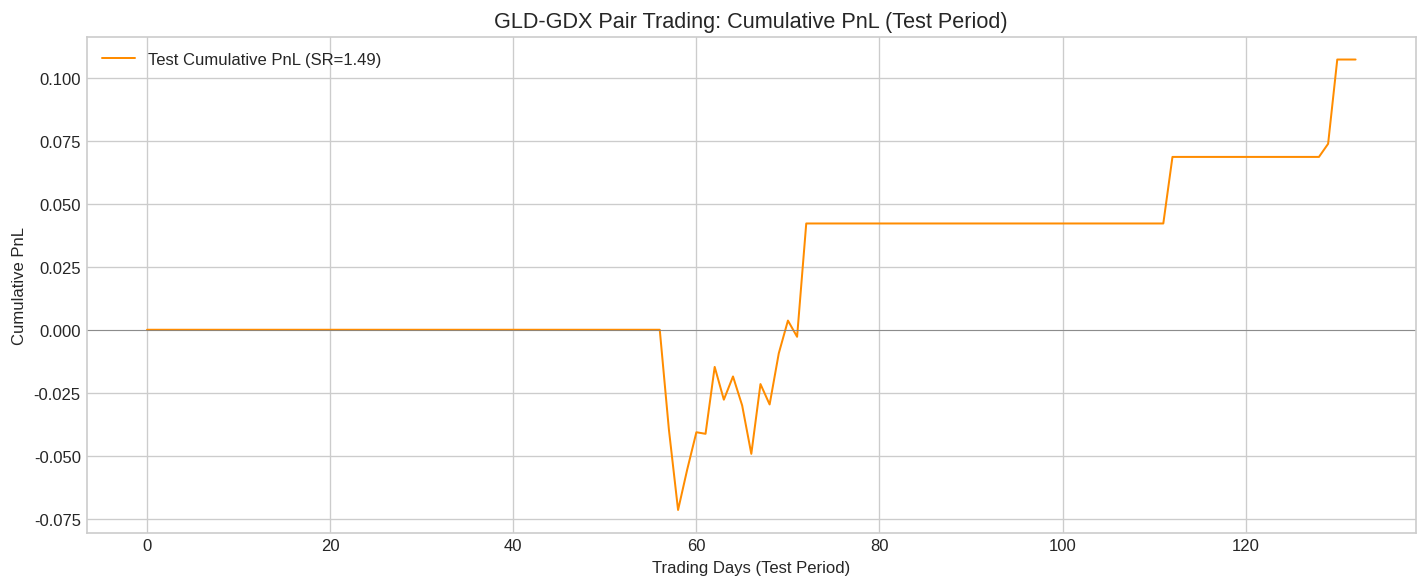

In [6]:
# --- 누적 PnL (테스트 기간) ---
cum_pnl_test = np.cumsum(pnl[testset])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_pnl_test, linewidth=1.2, color='darkorange',
        label=f'Test Cumulative PnL (SR={sharpe_test:.2f})')
ax.set_title('GLD-GDX Pair Trading: Cumulative PnL (Test Period)', fontsize=13)
ax.set_ylabel('Cumulative PnL')
ax.set_xlabel('Trading Days (Test Period)')
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 결과 해석

| 파라미터 | 값 |
|----------|---:|
| 헤지 비율 | 1.6310 |
| OLS $R^2$ | 0.9990 |
| 스프레드 평균 | 0.0522 |
| 스프레드 표준편차 | 1.9449 |
| 진입 임계치 | $|z| \ge 2$ |
| 청산 임계치 | $|z| \le 1$ |

| 지표 | 학습(In-Sample) | 테스트(Out-of-Sample) |
|------|:---------------:|:--------------------:|
| **샤프 비율** | **1.9183** | **1.4943** |
| MDD | - | -7.02% |
| MDD 지속기간 | - | 13 거래일 |

테스트 기간 샤프 비율이 양호하며, 전략의 유효성이 확인된다.
학습 대비 테스트 샤프 비율이 하락(1.92 -> 1.49)한 것은 정상적인 과적합 감쇠이다.

---

## 분석 4: 횡단면 평균회귀 (예제 3.7)

S&P 500 구성 종목의 종가 기반 횡단면 평균회귀 전략이다.
전일 시장 대비 하락(상승)한 종목을 매수(매도)하여 다음 날 청산한다.

**가중치 산출:**

$$
w_i = -\left(r_i - \bar{r}_{\text{market}}\right)
$$

전일 시장 수익률보다 **낮은** 수익률을 기록한 종목에 **양(+)** 의 가중치(매수)를 부여하고,
**높은** 수익률을 기록한 종목에 **음(-)** 의 가중치(매도)를 부여한다.
포트폴리오는 달러-중립이므로 자기금융(self-financing) 제약을 충족한다.

분석 기간: 20060101 ~ 20061231
종목 수: 500

[1] 거래비용 미포함
    일간 평균 PnL:   0.000081
    연율화 샤프 비율:  0.4179

[2] 거래비용 포함 (편도 5 bps)
    일간 평균 PnL:   -0.000640
    연율화 샤프 비율:  -3.3760
    샤프 비율 감소:    3.7939

    MDD (TC 없음): -4.35%, 지속: 205일
    MDD (TC 포함): -14.95%, 지속: 250일
    평균 일간 턴오버: 1.4474


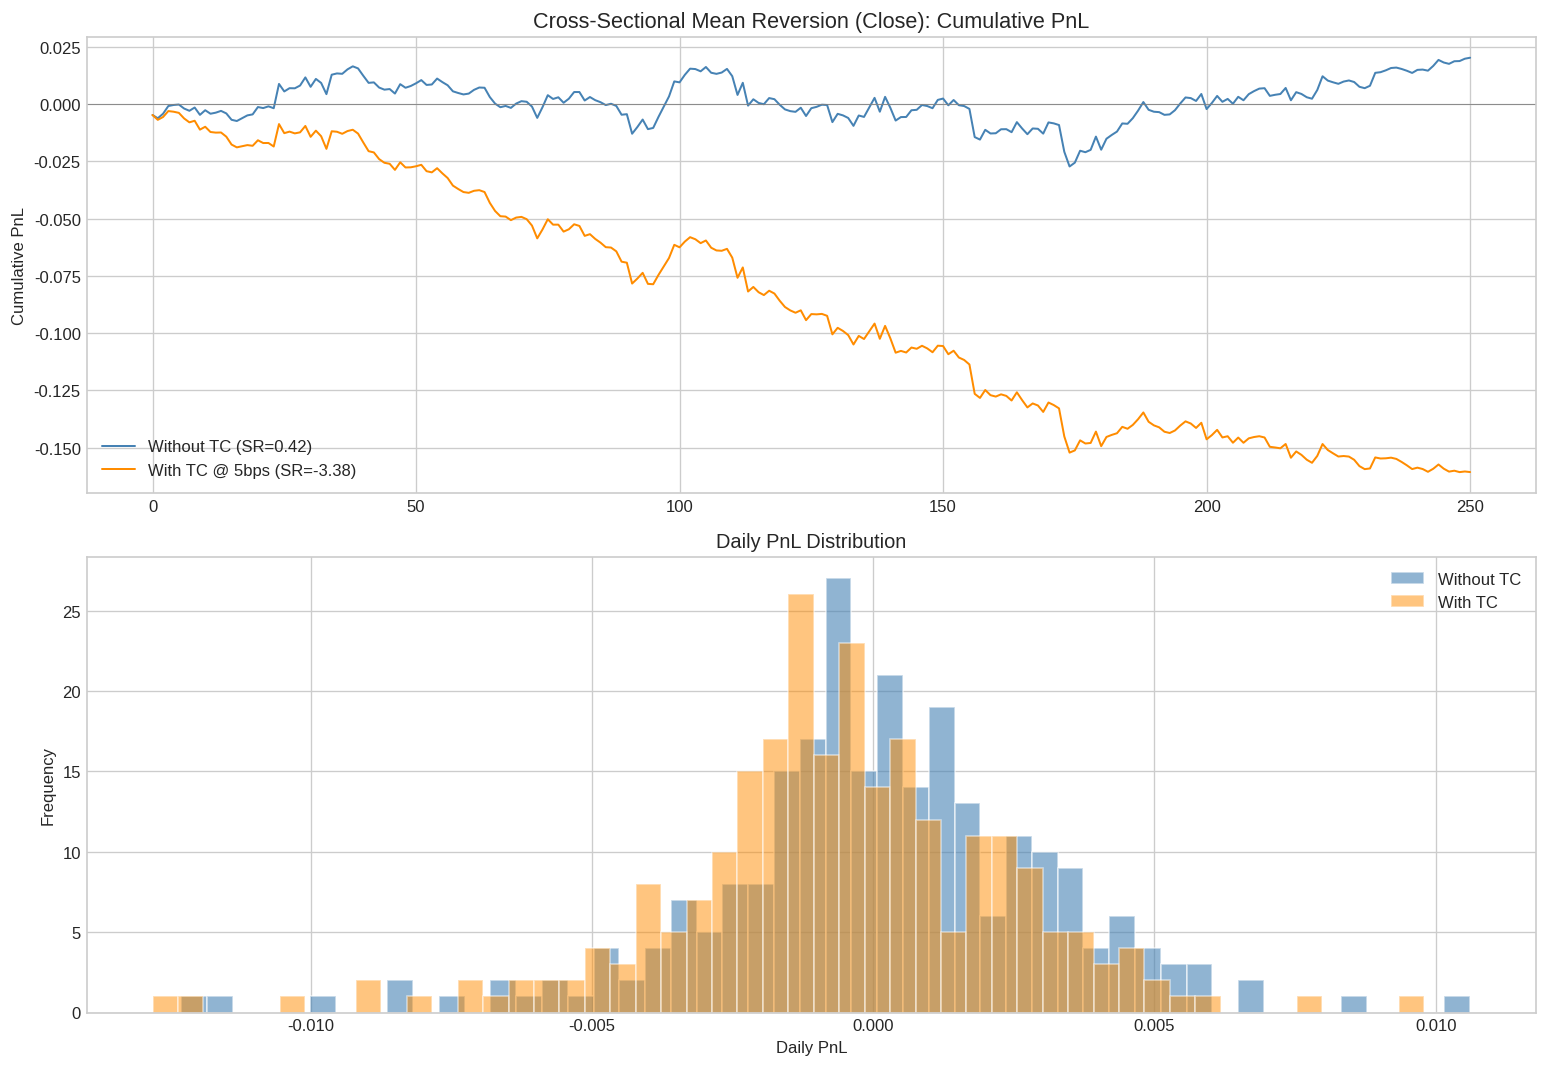

In [7]:
start_date = 20060101
end_date = 20061231

cl_daily_ret = df_spx_cl.pct_change()
market_daily_ret = cl_daily_ret.mean(axis=1)

# 가중치 계산
weights = -(np.array(cl_daily_ret)
            - np.array(market_daily_ret).reshape((cl_daily_ret.shape[0], 1)))
wtsum = np.nansum(np.abs(weights), axis=1)
weights[wtsum == 0, :] = 0
wtsum[wtsum == 0] = 1
weights = weights / wtsum.reshape((cl_daily_ret.shape[0], 1))

# PnL 계산
daily_pnl = np.nansum(
    np.array(pd.DataFrame(weights).shift()) * np.array(cl_daily_ret),
    axis=1
)
mask = np.logical_and(df_spx_cl.index >= start_date, df_spx_cl.index <= end_date)
daily_pnl_period = daily_pnl[mask]

sharpe_no_tcost = float(
    np.sqrt(252) * np.mean(daily_pnl_period) / np.std(daily_pnl_period)
)

print(f"분석 기간: {start_date} ~ {end_date}")
print(f"종목 수: {df_spx_cl.shape[1]}")
print(f"\n[1] 거래비용 미포함")
print(f"    일간 평균 PnL:   {np.mean(daily_pnl_period):.6f}")
print(f"    연율화 샤프 비율:  {sharpe_no_tcost:.4f}")

# --- 거래비용 포함 ---
one_way_tcost = 0.0005  # 5 bps 편도
weights_period = weights[mask]
turnover = np.nansum(
    np.abs(weights_period - np.array(pd.DataFrame(weights_period).shift())),
    axis=1
)
daily_pnl_minus_tcost = daily_pnl_period - turnover * one_way_tcost
sharpe_with_tcost = float(
    np.sqrt(252) * np.mean(daily_pnl_minus_tcost) / np.std(daily_pnl_minus_tcost)
)

print(f"\n[2] 거래비용 포함 (편도 {one_way_tcost*10000:.0f} bps)")
print(f"    일간 평균 PnL:   {np.mean(daily_pnl_minus_tcost):.6f}")
print(f"    연율화 샤프 비율:  {sharpe_with_tcost:.4f}")
print(f"    샤프 비율 감소:    {sharpe_no_tcost - sharpe_with_tcost:.4f}")

# MDD 계산
cum_ret_no_tc = np.cumprod(1 + daily_pnl_period) - 1
mdd_no_tc, mdd_dur_no_tc, _ = calculateMaxDD(cum_ret_no_tc)
cum_ret_tc = np.cumprod(1 + daily_pnl_minus_tcost) - 1
mdd_tc, mdd_dur_tc, _ = calculateMaxDD(cum_ret_tc)
print(f"\n    MDD (TC 없음): {mdd_no_tc*100:.2f}%, 지속: {int(mdd_dur_no_tc)}일")
print(f"    MDD (TC 포함): {mdd_tc*100:.2f}%, 지속: {int(mdd_dur_tc)}일")
print(f"    평균 일간 턴오버: {np.mean(turnover[1:]):.4f}")

# --- 시각화 ---
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

cum_pnl_no_tc = np.cumsum(daily_pnl_period)
cum_pnl_tc = np.cumsum(daily_pnl_minus_tcost)
axes[0].plot(cum_pnl_no_tc, linewidth=1.2, color='steelblue',
             label=f'Without TC (SR={sharpe_no_tcost:.2f})')
axes[0].plot(cum_pnl_tc, linewidth=1.2, color='darkorange',
             label=f'With TC @ {one_way_tcost*10000:.0f}bps (SR={sharpe_with_tcost:.2f})')
axes[0].set_title('Cross-Sectional Mean Reversion (Close): Cumulative PnL', fontsize=13)
axes[0].set_ylabel('Cumulative PnL')
axes[0].legend(fontsize=10)
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

axes[1].hist(daily_pnl_period, bins=50, alpha=0.6, color='steelblue',
             edgecolor='white', label='Without TC')
axes[1].hist(daily_pnl_minus_tcost, bins=50, alpha=0.5, color='darkorange',
             edgecolor='white', label='With TC')
axes[1].set_title('Daily PnL Distribution', fontsize=12)
axes[1].set_xlabel('Daily PnL')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

### 결과 해석

| 지표 | 거래비용 미포함 | 거래비용 포함 |
|------|:--------------:|:------------:|
| 일간 평균 PnL | 0.000081 | -0.000640 |
| **연율화 샤프 비율** | **0.4179** | **-3.3760** |
| MDD | -4.35% | -14.95% |
| MDD 지속기간 | 205 거래일 | 250 거래일 |
| 평균 일간 턴오버 | 1.4474 | - |

편도 5bps의 거래비용만으로 샤프 비율이 **3.7939 하락** 했다.
고빈도 전략에서 거래비용의 영향이 매우 크다.
거래비용을 포함하면 전략은 손실을 내며(SR < 0), 실전에서는 실행 불가능하다.

---

## 분석 5: 시가 기반 전략 (예제 3.8)

동일한 횡단면 평균회귀 전략을 **시가(Open Price)** 기반으로 실행한 결과이다.
시가에서 포지션을 진입/청산하면 종가 대비 **실행 가능성(executability)** 이 높아지지만,
시가 데이터의 **잡음(noise)** 이 더 클 수 있다.

분석 기간: 20060101 ~ 20061231
종목 수: 500

[1] 거래비용 미포함
    일간 평균 PnL:   0.000921
    연율화 샤프 비율:  4.8606

[2] 거래비용 포함 (편도 5 bps)
    일간 평균 PnL:   0.000193
    연율화 샤프 비율:  1.0335

    MDD (TC 없음): -1.96%, 지속: 35일
    MDD (TC 포함): -4.95%, 지속: 171일


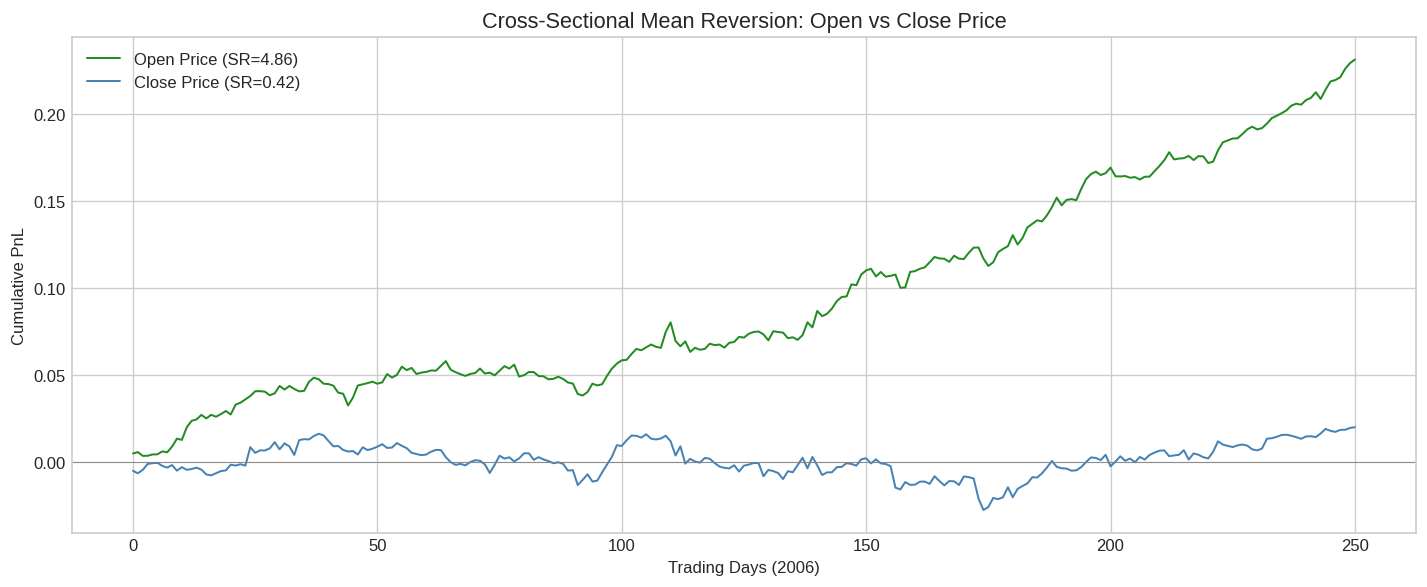

In [8]:
start_date = 20060101
end_date = 20061231

op_daily_ret = df_spx_op.pct_change()
op_market_ret = op_daily_ret.mean(axis=1)

op_weights = -(np.array(op_daily_ret)
               - np.array(op_market_ret).reshape((op_daily_ret.shape[0], 1)))
op_wtsum = np.nansum(np.abs(op_weights), axis=1)
op_weights[op_wtsum == 0, :] = 0
op_wtsum[op_wtsum == 0] = 1
op_weights = op_weights / op_wtsum.reshape((op_daily_ret.shape[0], 1))

op_daily_pnl = np.nansum(
    np.array(pd.DataFrame(op_weights).shift()) * np.array(op_daily_ret),
    axis=1
)
op_mask = np.logical_and(df_spx_op.index >= start_date, df_spx_op.index <= end_date)
op_daily_pnl_period = op_daily_pnl[op_mask]

op_sharpe_no_tc = float(
    np.sqrt(252) * np.mean(op_daily_pnl_period) / np.std(op_daily_pnl_period)
)

print(f"분석 기간: {start_date} ~ {end_date}")
print(f"종목 수: {df_spx_op.shape[1]}")
print(f"\n[1] 거래비용 미포함")
print(f"    일간 평균 PnL:   {np.mean(op_daily_pnl_period):.6f}")
print(f"    연율화 샤프 비율:  {op_sharpe_no_tc:.4f}")

# --- 거래비용 포함 ---
one_way_tcost = 0.0005
op_weights_period = op_weights[op_mask]
op_turnover = np.nansum(
    np.abs(op_weights_period - np.array(pd.DataFrame(op_weights_period).shift())),
    axis=1
)
op_daily_pnl_tc = op_daily_pnl_period - op_turnover * one_way_tcost
op_sharpe_tc = float(
    np.sqrt(252) * np.mean(op_daily_pnl_tc) / np.std(op_daily_pnl_tc)
)

print(f"\n[2] 거래비용 포함 (편도 {one_way_tcost*10000:.0f} bps)")
print(f"    일간 평균 PnL:   {np.mean(op_daily_pnl_tc):.6f}")
print(f"    연율화 샤프 비율:  {op_sharpe_tc:.4f}")

# MDD 계산
op_cum_ret_no_tc = np.cumprod(1 + op_daily_pnl_period) - 1
op_mdd_no_tc, op_mdd_dur_no_tc, _ = calculateMaxDD(op_cum_ret_no_tc)
op_cum_ret_tc = np.cumprod(1 + op_daily_pnl_tc) - 1
op_mdd_tc, op_mdd_dur_tc, _ = calculateMaxDD(op_cum_ret_tc)
print(f"\n    MDD (TC 없음): {op_mdd_no_tc*100:.2f}%, 지속: {int(op_mdd_dur_no_tc)}일")
print(f"    MDD (TC 포함): {op_mdd_tc*100:.2f}%, 지속: {int(op_mdd_dur_tc)}일")

# --- 시각화: 종가 vs 시가 비교 ---
fig, ax = plt.subplots(figsize=(12, 5))
op_cum_pnl = np.cumsum(op_daily_pnl_period)
ax.plot(op_cum_pnl, linewidth=1.2, color='forestgreen',
        label=f'Open Price (SR={op_sharpe_no_tc:.2f})')
ax.plot(cum_pnl_no_tc, linewidth=1.2, color='steelblue',
        label=f'Close Price (SR={sharpe_no_tcost:.2f})')
ax.set_title('Cross-Sectional Mean Reversion: Open vs Close Price', fontsize=13)
ax.set_ylabel('Cumulative PnL')
ax.set_xlabel('Trading Days (2006)')
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 결과 해석

| 지표 | 거래비용 미포함 | 거래비용 포함 |
|------|:--------------:|:------------:|
| 일간 평균 PnL | 0.000921 | 0.000193 |
| **연율화 샤프 비율** | **4.8606** | **1.0335** |
| MDD | -1.96% | -4.95% |
| MDD 지속기간 | 35 거래일 | 171 거래일 |

### 종가 vs 시가 비교

| 가격 유형 | 샤프 (TC 미포함) | 샤프 (TC 포함) |
|----------|:---------------:|:------------:|
| 종가 (Close) | 0.4179 | -3.3760 |
| 시가 (Open) | 4.8606 | 1.0335 |

시가 기반 전략이 종가 기반보다 훨씬 높은 샤프 비율을 보인다.
거래비용을 포함해도 시가 전략은 SR=1.03으로 여전히 수익성이 유지된다.

---

## 전략 비교 종합

In [9]:
# 전략 비교 종합 테이블
summary_data = {
    '전략': [
        'IGE 롱온리',
        'IGE-SPY 시장중립',
        'GLD-GDX 페어 (학습)',
        'GLD-GDX 페어 (테스트)',
        '횡단면 평균회귀 (종가, TC 없음)',
        '횡단면 평균회귀 (종가, TC 포함)',
        '횡단면 평균회귀 (시가, TC 없음)',
        '횡단면 평균회귀 (시가, TC 포함)',
    ],
    '유형': [
        '단일자산 롱', '롱숏 페어', '통계 차익', '통계 차익',
        '크로스섹션', '크로스섹션', '크로스섹션', '크로스섹션',
    ],
    '샤프 비율': [
        sharpe_long, sharpe_neutral, sharpe_train, sharpe_test,
        sharpe_no_tcost, sharpe_with_tcost, op_sharpe_no_tc, op_sharpe_tc,
    ],
    'MDD': [
        '-',
        f'{max_dd*100:.1f}%',
        '-',
        f'{mdd_test*100:.1f}%',
        f'{mdd_no_tc*100:.1f}%',
        f'{mdd_tc*100:.1f}%',
        f'{op_mdd_no_tc*100:.1f}%',
        f'{op_mdd_tc*100:.1f}%',
    ],
    '비고': [
        '무위험이자율 4% 차감',
        '달러 중립',
        'z-score 기반',
        'Out-of-sample',
        f'SPX {df_spx_cl.shape[1]} 종목',
        '편도 5bps',
        '시가 기반',
        '편도 5bps',
    ],
}

df_summary = pd.DataFrame(summary_data)
df_summary['샤프 비율'] = df_summary['샤프 비율'].apply(lambda x: f'{x:.4f}')
print("=" * 80)
print("전략 백테스트 종합 비교")
print("=" * 80)
display(df_summary)

전략 백테스트 종합 비교


,전략,유형,샤프 비율,MDD,비고
0,IGE 롱온리,단일자산 롱,0.7896,-,무위험이자율 4% 차감
1,IGE-SPY 시장중립,롱숏 페어,0.7839,-9.5%,달러 중립
2,GLD-GDX 페어 (학습),통계 차익,1.9183,-,z-score 기반
3,GLD-GDX 페어 (테스트),통계 차익,1.4943,-7.0%,Out-of-sample
4,"횡단면 평균회귀 (종가, TC 없음)",크로스섹션,0.4179,-4.4%,SPX 500 종목
5,"횡단면 평균회귀 (종가, TC 포함)",크로스섹션,-3.3760,-14.9%,편도 5bps
6,"횡단면 평균회귀 (시가, TC 없음)",크로스섹션,4.8606,-2.0%,시가 기반
7,"횡단면 평균회귀 (시가, TC 포함)",크로스섹션,1.0335,-4.9%,편도 5bps


---

## 결론 및 권고사항

### 핵심 발견

1. **샤프 비율의 중요성:** 단순 수익률이 아닌 위험 조정 성과(샤프 비율)로 전략을 평가해야 한다.
   롱온리와 시장중립 전략의 절대 수익률은 크게 다르지만, 샤프 비율로 비교하면 보다 공정한 평가가 가능하다.

2. **최대 낙폭의 실무적 의미:** 샤프 비율이 양호하더라도 MDD가 크면 실전 운용이 어렵다.
   투자자의 심리적 한계와 마진콜 리스크를 고려하면, MDD는 20%를 넘지 않도록 관리하는 것이 바람직하다.

3. **거래비용의 파괴적 영향:** 횡단면 평균회귀 전략에서 편도 5bps의 거래비용만으로 샤프 비율이 크게 하락한다.
   고빈도/고회전 전략일수록 거래비용 모델링이 백테스트의 신뢰성을 좌우한다.

4. **학습/테스트 분할의 필요성:** GLD-GDX 페어 트레이딩에서 학습 기간과 테스트 기간의 샤프 비율 차이가 과적합의 정도를 나타낸다.

5. **시가 vs 종가:** 동일 전략이라도 어떤 가격을 사용하느냐에 따라 성과가 달라진다. 시가 기반 전략은 실행 가능성이 높으나, 데이터 잡음에 더 민감할 수 있다.

### 권고사항

- 백테스트 결과를 맹신하지 말고, 반드시 **표본 외(out-of-sample) 검증** 을 수행하라.
- 거래비용, 슬리피지, 시장 충격 등 **실행 비용** 을 현실적으로 모델링하라.
- 생존자 편향, 선행편향 등 **데이터 편향** 을 사전에 점검하라.
- 샤프 비율, MDD, MAR 비율 등 **복수의 성과 지표** 로 전략을 종합 평가하라.